In [1]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
import json

# 1. Redefine your network architecture
class AnyLengthRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(AnyLengthRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, nonlinearity='relu')
        self.linear = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed_emb = pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        _, h_n = self.rnn(packed_emb)
        prediction = self.linear(h_n[-1, :, :])
        return prediction.squeeze()

# 2. Load the vocabulary
model_path = 'rnn_OhioT1DM.pth'
vocab_path = 'vocabulary_OhioT1DM.json'

with open(vocab_path, 'r') as f:
    loaded_vocab = json.load(f)

vocab_size = len(loaded_vocab) + 1  # +1 for Padding (0)
print(f"Loaded vocabulary: {loaded_vocab}")

# 3. Instantiate the empty model (with the same parameters used during training)
loaded_model = AnyLengthRNN(vocab_size=vocab_size, embed_dim=8, hidden_dim=32)

# 4. Fill the empty model with the saved weights
loaded_model.load_state_dict(torch.load(model_path))

# 5. CRITICAL! Set the model to Evaluation mode
loaded_model.eval()
print("✅ Model successfully loaded and ready for inference (or WFA extraction).")

# Assigning to final variables for later use
model = loaded_model
vocab = loaded_vocab

Loaded vocabulary: {'N': 1, 'M': 2, 'I': 3, 'E': 4}
✅ Model successfully loaded and ready for inference (or WFA extraction).


C:\Users\rafam\AppData\Local\Temp\ipykernel_7092\1482951475.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(model_path))


In [5]:
import sys
import os

# Adjust this path to your local directory if necessary
project_path = r'C:\Users\rafam\Documents\GITI7\TFM\Codigo\TropicalSemirring_Functions'
if project_path not in sys.path:
    sys.path.append(project_path)

from QuantitativeObservationTable import (
    QuantitativeObservationTable, 
    QuantitativeObservationTableParameters
)

# Import the newly unified Oracle class
from TrainedRNNOracle import TrainedRNNOracle

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
vocab = {'N': 1, 'M': 2, 'I': 3, 'E': 4}

# 'model' is the RNN variable trained in the previous step
# We instantiate the unified Oracle with the specific tolerance from the dirty code
oracle = TrainedRNNOracle(rnn_model=model, vocab_dict=vocab, tol=40.0, rounding_step=1)

params = QuantitativeObservationTableParameters(
    tol_dist_init=20.0, 
    prefix_limit=50, 
    suffix_limit=25, 
    patience=5000, 
    rec_method="direct", 
    r=40, 
)

table = QuantitativeObservationTable(
    alphabet=oracle.alphabet,
    membership_query=oracle.calculate_weight, # Clean pointer to the RNN's MQ
    parameters=params
)

seen_counterexamples = set()
iteration = 1

print("Starting active learning loop with Neural Network Oracle...")

# ==========================================
# 2. MAIN L* LOOP
# ==========================================
while True:
    print(f"\n--- Iteration {iteration} ---")
    table.make_table_closed_and_consistent()
            
    # Reconstruct Hypothesis WFA
    wfa = table.reconstruct_WFA()
    
    # Equivalence Query using the unified method dispatcher
    ce = oracle.equivalence_query(
        wfa, 
        method="hybrid", 
        exhaustive_len=6, 
        random_max_len=10, 
        num_random=0
    )

    # Evaluate Equivalence Query Results
    if ce is None:
        print(f"\n[SUCCESS] No counterexamples found.")
        print(f"Extraction complete in {iteration} iterations. Total states: {len(table.S)}")
        break

    if ce in seen_counterexamples:
        print(f"\n[STOP] Repeated counterexample '{ce}' detected. Check tolerances or network precision.")
        break

    print(f"[+] Processing Counterexample: '{ce}' | S size: {len(table.S)}")

    # Process Counterexample using Binary Search as defined in the original code
    table.process_counterexample(ce, hypothesis_wfa=wfa, method="binary_search")
    seen_counterexamples.add(ce) 
    
    iteration += 1

Starting active learning loop with Neural Network Oracle...

--- Iteration 1 ---
  [EQ-Hybrid] Phase 1: Exhaustive search up to length 6...
      -> Failure detail for 'EIEN': RNN=-47.00, WFA=-2.00

[!] Counterexample found (Exhaustive): 'EIEN'
[+] Processing Counterexample: 'EIEN' | S size: 1
[Counterexample PAC] Binary search found the crucial suffix: 'IEN' from 'EIEN'
Test classify 'MMIIII': 22.0
Test classify 'MMMMII': 2.0

--- Iteration 2 ---
  [EQ-Hybrid] Phase 1: Exhaustive search up to length 6...
      -> Failure detail for 'NMMEI': RNN=18.00, WFA=-22.00

[!] Counterexample found (Exhaustive): 'NMMEI'
[+] Processing Counterexample: 'NMMEI' | S size: 3
[Counterexample PAC] Binary search found the crucial suffix: 'I' from 'NMMEI'
Test classify 'MMIIII': 21.0
Test classify 'MMMMII': 29.0

--- Iteration 3 ---
  [EQ-Hybrid] Phase 1: Exhaustive search up to length 6...
      -> Failure detail for 'NMMEE': RNN=13.00, WFA=-31.00

[!] Counterexample found (Exhaustive): 'NMMEE'
[+] Proc

KeyboardInterrupt: 

In [9]:
import sys
import os

# Adjust this path to your local directory if necessary
project_path = r'C:\Users\rafam\Documents\GITI7\TFM\Codigo\TropicalSemirring_Functions'
if project_path not in sys.path:
    sys.path.append(project_path)

from QuantitativeObservationTable import (
    QuantitativeObservationTable, 
    QuantitativeObservationTableParameters
)

# Import the newly unified Oracle class
from TrainedRNNOracle import TrainedRNNOracle

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
vocab = {'N': 1, 'M': 2, 'I': 3, 'E': 4}

# 'model' is the RNN variable trained in the previous step.
# We instantiate the unified Oracle with the specific tolerance from the dirty code.
# Note: max_eq_length is no longer passed here, it goes directly to the equivalence query.
oracle = TrainedRNNOracle(rnn_model=model, vocab_dict=vocab, tol=37.0, rounding_step=1)

params = QuantitativeObservationTableParameters(
    tol_dist_init=20.0, 
    prefix_limit=50, 
    suffix_limit=25, 
    patience=5000, 
    rec_method="direct", 
    r=40
)

table = QuantitativeObservationTable(
    alphabet=oracle.alphabet,
    membership_query=oracle.calculate_weight, # Clean pointer to the RNN's MQ
    parameters=params
)

seen_counterexamples = set()
iteration = 1

print("Starting active learning loop with Neural Network Oracle...")

# ==========================================
# 2. MAIN L* LOOP
# ==========================================
while True:
    print(f"\n--- Iteration {iteration} ---")
    table.make_table_closed_and_consistent()
            
    # Reconstruct Hypothesis WFA
    wfa = table.reconstruct_WFA()
    
    # Equivalence Query using the unified method dispatcher for Max-Plus Abstraction
    # We pass the max_eq_length and M_threshold directly here
    ce = oracle.equivalence_query(
        wfa, 
        method="abstraction", 
        max_eq_length=6, 
        M_threshold=10
    )

    # Evaluate Equivalence Query Results
    if ce is None:
        print(f"\n[SUCCESS] No counterexamples found.")
        print(f"Extraction complete in {iteration} iterations. Total states: {len(table.S)}")
        break

    if ce in seen_counterexamples:
        print(f"\n[STOP] Repeated counterexample '{ce}' detected. Check tolerances or network precision.")
        break

    print(f"[+] Processing Counterexample: '{ce}' | S size: {len(table.S)}")

    # Process Counterexample using Binary Search
    table.process_counterexample(ce, hypothesis_wfa=wfa, method="binary_search")
    seen_counterexamples.add(ce)  
    
    iteration += 1

Starting active learning loop with Neural Network Oracle...

--- Iteration 1 ---
  [EQ-Abstraction] Starting Max-Plus regression-guided search (Max Len: 6)...
      -> Failure detail for 'NMMIE': RNN=33.00, WFA=-4.00

[!] Counterexample found (Abstraction): 'NMMIE'
[+] Processing Counterexample: 'NMMIE' | S size: 1
[Counterexample PAC] Binary search found the crucial suffix: 'IE' from 'NMMIE'

--- Iteration 2 ---
  [EQ-Abstraction] Starting Max-Plus regression-guided search (Max Len: 6)...
      -> Failure detail for 'NMMMN': RNN=24.00, WFA=-14.00

[!] Counterexample found (Abstraction): 'NMMMN'
[+] Processing Counterexample: 'NMMMN' | S size: 2
[Counterexample PAC] Binary search found the crucial suffix: 'MN' from 'NMMMN'

--- Iteration 3 ---
  [EQ-Abstraction] Starting Max-Plus regression-guided search (Max Len: 6)...
      -> Failure detail for 'NMMMMN': RNN=35.00, WFA=-17.00

[!] Counterexample found (Abstraction): 'NMMMMN'
[+] Processing Counterexample: 'NMMMMN' | S size: 2
[Count

KeyboardInterrupt: 

Looking for WFAs in the current directory...
Found 4 WFA files. Loading...
 -> Loaded WFA_Abstraction_Big.pkl: 853 states.
 -> Loaded WFA_Abstraction_Small.pkl: 252 states.
 -> Loaded WFA_Exhaustive_Big.pkl: 854 states.
 -> Loaded WFA_Exhaustive_Small.pkl: 253 states.

Generating test sets and calculating Baseline...
  Length 1: Baseline Mean = -0.25 (calculated from 4 words)
    -> Test: 4 words (Exhaustive)
  Length 2: Baseline Mean = 0.50 (calculated from 16 words)
    -> Test: 16 words (Exhaustive)
  Length 3: Baseline Mean = -2.70 (calculated from 64 words)
    -> Test: 64 words (Exhaustive)
  Length 4: Baseline Mean = -6.98 (calculated from 256 words)
    -> Test: 256 words (Exhaustive)
  Length 5: Baseline Mean = -15.02 (calculated from 1024 words)
    -> Test: 500 words (Randomized)
  Length 6: Baseline Mean = -19.87 (calculated from 2000 words)
    -> Test: 500 words (Randomized)
  Length 7: Baseline Mean = -20.10 (calculated from 2000 words)
    -> Test: 500 words (Randomized

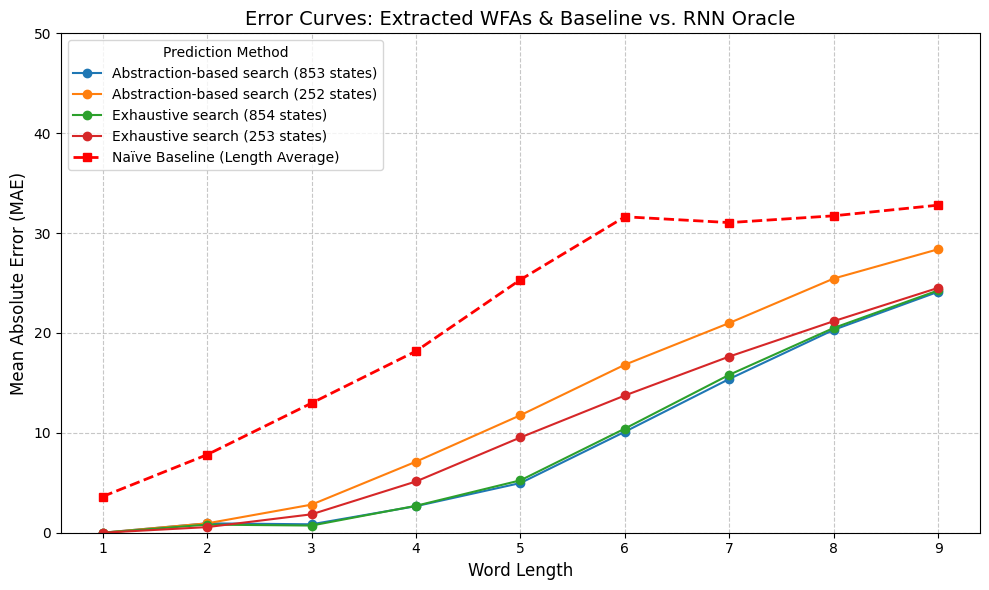

In [25]:
import os
import glob
import pickle
import itertools
import random
import matplotlib.pyplot as plt
import numpy as np
from TrainedRNNOracle import TrainedRNNOracle
from QuantitativeObservationTable import (
    QuantitativeObservationTable, 
    QuantitativeObservationTableParameters
)

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


oracle = TrainedRNNOracle(rnn_model=model, vocab_dict=vocab)
alphabet = ['N', 'M', 'I', 'E']

# SET TO CURRENT DIRECTORY: Looks in the same folder as the .ipynb file
file_path = "." 
lengths = list(range(1, 10))

# --- 1. Load the specific WFAs for this test ---
print(f"Looking for WFAs in the current directory...")
search_pattern = os.path.join(file_path, "WFA_*.pkl")
pkl_files = sorted(glob.glob(search_pattern))

# Debugging check to ensure files are actually being found
if not pkl_files:
    print(f"\n[!] ERROR: No files matching 'WFA_*.pkl' were found in the current directory.")
else:
    print(f"Found {len(pkl_files)} WFA files. Loading...")

loaded_wfas = {}
for path in pkl_files:
    with open(path, 'rb') as f:
        wfa = pickle.load(f)
        num_states = len(wfa.q0)
        file_name = os.path.basename(path)
        loaded_wfas[file_name] = wfa
        print(f" -> Loaded {file_name}: {num_states} states.")

# --- 2. Calculate Baseline Means and Generate Test Sets ---
print("\nGenerating test sets and calculating Baseline...")
baseline_means = {}
test_words_by_length = {}

for length in lengths:
    # Generate all possible combinations
    all_possible = [''.join(p) for p in itertools.product(alphabet, repeat=length)]
    random.shuffle(all_possible) # Shuffle to ensure randomness
    
    # a) Determine which words are used to calculate the mean weight
    if length >= 6:
        # For L>=6 use 2000 random words for the mean
        words_for_mean = all_possible[:2000]
        # Leave the rest for validation without repeating words
        validation_pool = all_possible[2000:] 
    else:
        # For L<6 use all for the mean
        words_for_mean = all_possible
        # Since we use all for the mean, overlapping for validation is unavoidable
        validation_pool = all_possible 
    
    # Calculate the mean weight (our "Baseline prediction" for this length)
    weights = [oracle.calculate_weight(w) for w in words_for_mean]
    length_mean = sum(weights) / len(weights)
    baseline_means[length] = length_mean
    print(f"  Length {length}: Baseline Mean = {length_mean:.2f} (calculated from {len(words_for_mean)} words)")
    
    # b) Determine the validation/test set
    if length <= 4:
        test_words = all_possible
        print(f"    -> Test: {len(test_words)} words (Exhaustive)")
    else: 
        # For lengths >= 5
        # Select 500 from the available pool
        test_words = random.sample(validation_pool, 500)
        print(f"    -> Test: 500 words (Randomized)")
        
    test_words_by_length[length] = test_words

# --- 3. Error Calculation (MAE) for WFAs and Baseline ---
print("\nCalculating errors against the Oracle. This might take a few seconds...")
wfa_errors = {name: [] for name in loaded_wfas.keys()}
baseline_errors = []

for length in lengths:
    test_words = test_words_by_length[length]
    pred_baseline = baseline_means[length]
    
    accumulated_baseline_error = 0.0
    accumulated_wfa_errors = {name: 0.0 for name in loaded_wfas.keys()}
    
    for word in test_words:
        pred_oracle = oracle.calculate_weight(word)
        
        # 1. Add baseline error
        accumulated_baseline_error += abs(pred_baseline - pred_oracle)
        
        # 2. Add WFA errors
        for name, wfa in loaded_wfas.items():
            pred_wfa = wfa.classify_word(word)
            
            if pred_wfa == float('-inf') and pred_oracle == float('-inf'):
                error_abs = 0.0
            elif pred_wfa == float('-inf') or pred_oracle == float('-inf'):
                error_abs = 100.0 
            else:
                error_abs = abs(pred_wfa - pred_oracle)
                
            accumulated_wfa_errors[name] += error_abs
            
    # Calculate averages for the current length
    baseline_errors.append(accumulated_baseline_error / len(test_words))
    for name in loaded_wfas.keys():
        wfa_errors[name].append(accumulated_wfa_errors[name] / len(test_words))

print("Calculations finished!")

# --- 4. Plotting the Error Curves ---
plt.figure(figsize=(10, 6))

# Plot WFAs
for name, wfa in loaded_wfas.items():
    num_states = len(wfa.q0)
    error_list = wfa_errors[name]
    
    # Customizing the legend based on the new file names
    name_lower = name.lower()
    
    if 'exhaustive' in name_lower:
        method = "Exhaustive search"
    elif 'abstraction' in name_lower:
        method = "Abstraction-based search"
    else:
        method = "Extracted Model"
        
    label = f"{method} ({num_states} states)"
    plt.plot(lengths, error_list, marker='o', label=label)

# Plot Baseline
plt.plot(lengths, baseline_errors, marker='s', color='red', linestyle='--', linewidth=2, label='Naïve Baseline (Length Average)')

# English titles and formatting
plt.title('Error Curves: Extracted WFAs & Baseline vs. RNN Oracle', fontsize=14)
plt.xlabel('Word Length', fontsize=12)
plt.ylabel('Mean Absolute Error (MAE)', fontsize=12)

plt.xticks(lengths)
plt.ylim(0, 50) 

plt.legend(title="Prediction Method", loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# --- 5. Save and Show the Image ---
save_path = os.path.join(file_path, "wfa_and_baseline_comparisons.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nPlot successfully saved at:\n{save_path}")

plt.show()